# Разведочный анализ данных (EDA)

Третий шаг проекта: исследуем очищенные данные, чтобы понять, есть ли системные различия между банками и продуктами, и сформулировать гипотезы для дальнейшей проверки.

**Что делаем:** смотрим на распределение оценок по банкам и продуктам, ищем закономерности в разрезе банк x продукт, анализируем динамику по месяцам, проводим частотный анализ текста жалоб. По ходу анализа находим кандидатов на более глубокую проверку - их разбор вынесен в ноутбук **[4.tests](4.tests.ipynb)**.

**Результат ноутбука:** набор наблюдений и рабочих гипотез, главная из которых - влияние платных программ вознаграждения за отзывы на распределение оценок между банками. Статистическая проверка этой и других гипотез - в ноутбуке **[4.tests](4.tests.ipynb)**.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 0. Приведем колонки к нужным типам данных

In [3]:
reviews = pd.read_csv("reviews_clean.csv")
reviews_by_bank = pd.read_csv("reviews_by_bank.csv")

In [3]:
print(reviews.dtypes, "\n")
print(reviews_by_bank.dtypes)

id                        int64
title                    object
userName                 object
text                     object
grade                   float64
commentCount              int64
dateCreate               object
resolutionIsApproved     object
bank                     object
product                  object
text_len                  int64
dtype: object 

bank                     object
id                        int64
title                    object
userName                 object
text                     object
grade                   float64
commentCount              int64
dateCreate               object
resolutionIsApproved     object
text_len                  int64
product                  object
dtype: object


In [4]:
reviews.head()

,id,title,userName,text,grade,commentCount,dateCreate,resolutionIsApproved,bank,product,text_len
0,13298418,Решение вопроса по действующей ипотеке,user-350426094886,У меня не списывались в срок деньги по ипотеке...,5.0,0,2026-08-14 10:09:01,NaN,sovcombank,hypothec,307
1,13294217,Страхование ипотеки,user-391523901770,12.08.2026 г. в 09:49 я обратилась в чат банка...,5.0,1,2026-08-12 10:22:35,NaN,sovcombank,hypothec,472
2,13292045,Повышение ставки по ипотеке,Mr.electrogreen,Здравствуйте! Прошу решить проблему по повышен...,1.0,2,2026-08-11 12:08:23,NaN,sovcombank,hypothec,2877
3,13291806,Благодарность оператору Полине,NtWqA9ba,Уже который раз оператор Полина помогает решит...,5.0,3,2026-08-11 10:50:23,NaN,sovcombank,hypothec,836
4,13289548,Консультация специалиста,user-770826034738,"Сегодня, 10 августа 2026г, в 9:44 по Мск я обр...",5.0,1,2026-08-10 10:24:12,NaN,sovcombank,hypothec,414


In [5]:
reviews_by_bank.head()

,bank,id,title,userName,text,grade,commentCount,dateCreate,resolutionIsApproved,text_len,product
0,alfabank,12454925,Мгновенное решение проблемы,user-467221820067,18 июня обратилась в чат с банком о непонятном...,5.0,1,2025-08-01 00:12:45,NaN,304,['debitcards']
1,alfabank,12454929,Подписки,user-762722410730,Замечатльное обслуживани. Решила оформить дебе...,5.0,1,2025-08-01 00:16:00,NaN,326,['debitcards']
2,alfabank,12454931,Дополнительные услуги по дебетовой карте,user-338017045330,"С удивлением обнаружил, что взымается комиссия...",4.0,2,2025-08-01 00:17:13,NaN,562,['debitcards']
3,alfabank,12454933,Списали плату за обслуживание стикера,user-90816582316,14.07.2025 заказ по акции с бесплатным обслужи...,1.0,3,2025-08-01 00:18:21,NaN,363,['debitcards']
4,alfabank,12454936,Не было доступа к карте,user-778622410773,23 июля обратился в отделение около метро Яшьл...,5.0,1,2025-08-01 00:20:38,NaN,357,"['transfers', 'debitcards']"


Колонки **resolutionIsApproved** в обоих фреймах -> **boolean**  
Приводим именно к `'boolean'` (не к обычному `bool`) - это сохраняет пропуски как NA, а не превращает их в False. Этот выбор обсуждался в ноутбуке  **[2.Cleaning&structuring](2.Cleaning&structuring.ipynb)**: пропуск здесь означает "это не жалоба", а не "жалоба не решена", поэтому терять эту информацию нельзя.

In [4]:
reviews['resolutionIsApproved'] = reviews['resolutionIsApproved'].astype('boolean')
reviews_by_bank['resolutionIsApproved'] = reviews_by_bank['resolutionIsApproved'].astype('boolean')

Колонки **dateCreate** в обоих фреймах -> **datetime**

In [5]:
reviews['dateCreate'] = pd.to_datetime(reviews['dateCreate'])
reviews_by_bank['dateCreate'] = pd.to_datetime(reviews_by_bank['dateCreate'])

Колонки **bank** в обоих фреймах -> **category**  
Колонка **product** в reviews -> **category**  
Колонка **product** в reviews_by_bank -> **list**  

In [5]:
reviews['bank'] = reviews['bank'].astype('category')
reviews['product'] = reviews['product'].astype('category')

Колонка `product` в `reviews_by_bank` при сохранении в CSV превратилась из списка в строку - восстанавливаем список через `ast.literal_eval`

In [6]:
import ast

reviews_by_bank['bank'] = reviews_by_bank['bank'].astype('category')
reviews_by_bank['product'] = reviews_by_bank['product'].apply(ast.literal_eval)

В итоге получились такие типы данных у каждой колонки:

In [7]:
print("============== reviews ==============\n", reviews.dtypes, "\n")
print("========== reviews_by_bank ==========\n", reviews_by_bank.dtypes)

============== reviews ==============
 id                               int64
title                           object
userName                        object
text                            object
grade                          float64
commentCount                     int64
dateCreate              datetime64[ns]
resolutionIsApproved           boolean
bank                          category
product                       category
text_len                         int64
dtype: object 

========== reviews_by_bank ==========
 bank                          category
id                               int64
title                           object
userName                        object
text                            object
grade                          float64
commentCount                     int64
dateCreate              datetime64[ns]
resolutionIsApproved           boolean
text_len                         int64
product                         object
dtype: object


## 1. Распределение grade внутри каждого банка

In [8]:
reviews_by_bank.groupby('bank', observed=False)['grade'].describe()

,count,mean,std,min,25%,50%,75%,max
bank,,,,,,,,
alfabank,76036.0,4.747909,0.906825,1.0,5.0,5.0,5.0,5.0
sberbank,4019.0,1.612093,1.281861,1.0,1.0,1.0,1.0,5.0
sovcombank,42639.0,4.815756,0.797831,1.0,5.0,5.0,5.0,5.0
tcs,15367.0,4.193401,1.554787,1.0,5.0,5.0,5.0,5.0
vtb,6032.0,2.827089,1.922415,1.0,1.0,2.0,5.0,5.0


In [9]:
grade_share = reviews_by_bank.groupby('bank', observed=False)['grade'].value_counts(normalize=True).unstack().sort_index(axis=1)
grade_share

grade,1.0,2.0,3.0,4.0,5.0
bank,,,,,
alfabank,0.049450,0.005774,0.002867,0.031235,0.910674
sberbank,0.759144,0.092809,0.033093,0.006718,0.108236
sovcombank,0.038134,0.003987,0.002345,0.015057,0.940477
tcs,0.178239,0.018091,0.006898,0.025574,0.771198
vtb,0.489556,0.055040,0.019397,0.010776,0.425232


В таблице выше в каждой ячейке расположена доля оценки grade среди отзывов банка bank

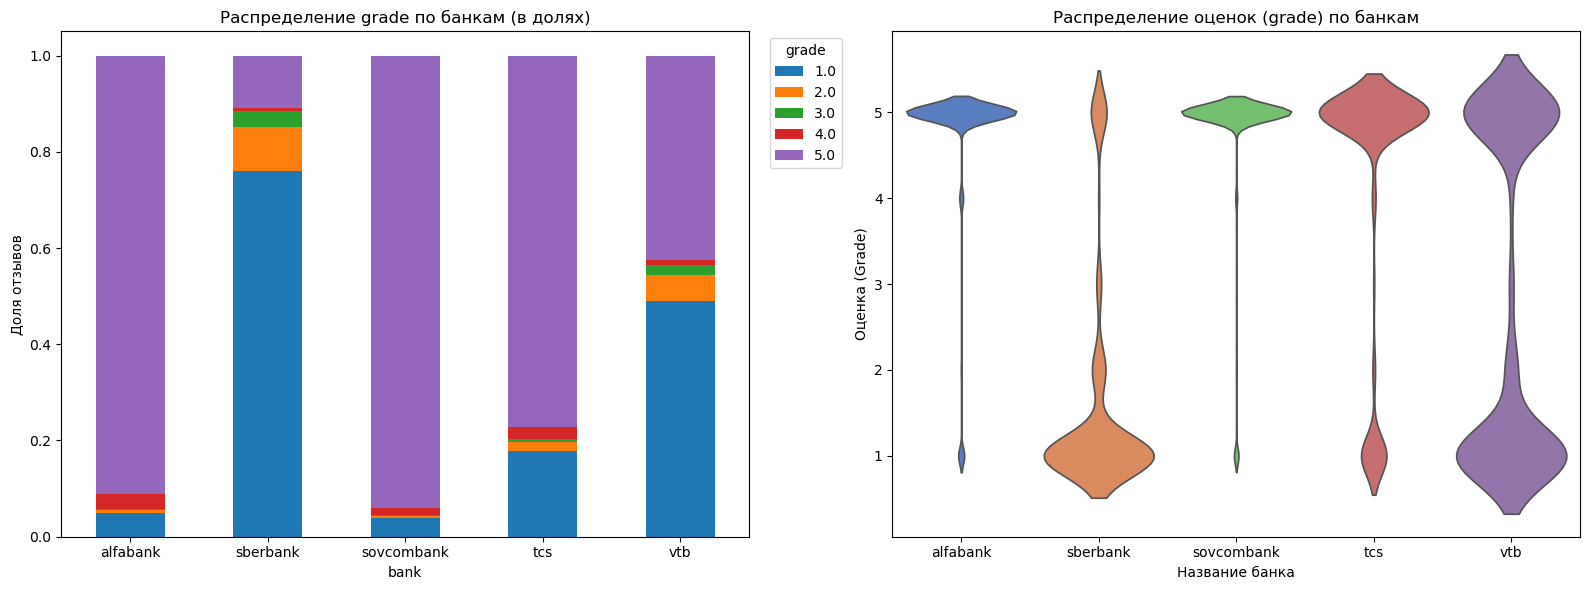

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

grade_share.plot(kind='bar', stacked=True, ax=ax1, linewidth=0)
ax1.set_ylabel('Доля отзывов')
ax1.set_title('Распределение grade по банкам (в долях)')
ax1.legend(title='grade', bbox_to_anchor=(1.02, 1), loc='upper left')

sns.violinplot(
    data=reviews_by_bank, 
    x="bank", 
    y="grade", 
    hue="bank", 
    palette="muted", 
    legend=False, 
    inner=None,
    ax=ax2
)
ax2.set_title('Распределение оценок (grade) по банкам')
ax2.set_xlabel('Название банка')
ax2.set_ylabel('Оценка (Grade)')

ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

#### Вывод

Распределение оценок резко отличается по банкам:  
* **Альфа-Банк** (mean 4.75) и **Совкомбанк** (mean 4.82) - почти полностью в grade 4-5 (90%+), крайне низкий разброс
* **Т-Банк** (mean 4.19) - более смешанное распределение: есть заметная доля grade=1 (~20%) наряду с преобладающими 5
* **ВТБ** (mean 2.83, ~50% grade=1) и **Сбербанк** (mean 1.61, ~75% grade=1) - оба выраженно негативны

Такой разброс - не случайность. По открытым источникам, у Альфа-Банка, Совкомбанка и Т-Банка действуют программы вознаграждения за отзыв с оценкой 4-5 на banki.r. Это даёт правдоподобное объяснение наблюдаемой картины. Ниже приведена более подробная информация по акциям.  
* **Акция Альфа-Банка** - [условия](https://alfabank.ru/feedback/banki-ru/300/)  
  Банк выплачивает 500р за зачтенный отзыв с оценкой 4-5 на сайте banki.ru. Можно получить до двух вознаграждений за месяц.
* **Совкомбанк** - [условия](https://bonus.sovcombank.ru/)  
  За зачтенный отзыв с оценкой 4-5 на сайте banki.ru банк начисляет 500 баллов на бонусный счет карты «Халва». Баллы - это внутренняя валюта программы лояльности карты «Халва» от Совкомбанка, где 1 балл равен 1 рублю. Накопленные баллы нельзя напрямую обналичить в банкомате, но ими можно полностью компенсировать свои прошлые покупки.
* **Т-банк**  
  В данный момент действует акция на самом банки.ру - [условие](https://www.banki.ru/specials/other/bonus_za_otzyv_banki/).  
  По условиям акции можно получить 1000 банкимани за зачтенный отзыв с оценкой 4-5. Затем можно обменять банкимани на сертификаты онлайн-магазинов или вывести на карту по курсу 1 банкимани = 1 рубль.  
* **ВТБ**
  Банк не проводит постоянную акцию с вознаграждением за отзыв на портале Банки.ру  
* **Сбербанк**
  Банк не проводит постоянную акцию с вознаграждением за отзыв на портале Банки.ру

Похоже, без денежного стимула banki.ru используется в основном как канал жалоб: довольный клиент редко пишет отзыв просто так, а недовольный - целенаправленно, чтобы добиться решения проблемы.

**Гипотеза для проверки:** наличие денежного вознаграждения за отзыв - основной фактор, объясняющий различия в распределении оценок между банками. Проверяется далее: на разрезе банк x продукт, во временной динамике и статистическим тестом (см. ноутбук **[4.tests](4.tests.ipynb)**).

## 2. Распределение grade по продуктам (независимо от банка)
`individual` и `currency_exchange` исключаем из сравнения - на них приходится всего 17 и 89 отзывов соответственно (из 175 315), что на порядок меньше остальных продуктов (следующий по объёму - `restructing`, 1 516 отзывов). При таком количестве отзывов среднее и распределение grade статистически неустойчиво - делать содержательные выводы нельзя. Сами строки при этом не удаляются из датасета, они по-прежнему участвуют в общих метриках по банку.

In [11]:
reviews_filtered = reviews[~reviews['product'].isin(['individual', 'currency_exchange'])]
reviews_filtered.groupby('product', observed=True)['grade'].describe().sort_values('mean')

,count,mean,std,min,25%,50%,75%,max
product,,,,,,,,
hypothec,2694.0,2.008166,1.615905,1.0,1.0,1.0,2.0,5.0
credits,4917.0,3.907057,1.742619,1.0,2.0,5.0,5.0,5.0
restructing,1516.0,3.931398,1.718251,1.0,2.0,5.0,5.0,5.0
other,6623.0,4.307867,1.465565,1.0,5.0,5.0,5.0,5.0
transfers,7065.0,4.325548,1.455514,1.0,5.0,5.0,5.0,5.0
autocredits,2514.0,4.407319,1.381030,1.0,5.0,5.0,5.0,5.0
creditcards,24669.0,4.499128,1.277197,1.0,5.0,5.0,5.0,5.0
deposits,7796.0,4.505387,1.270314,1.0,5.0,5.0,5.0,5.0
debitcards,77249.0,4.632099,1.101107,1.0,5.0,5.0,5.0,5.0


In [12]:
g = reviews_filtered.groupby('product', observed=True)
grade_share_product = g['grade'].value_counts(normalize=True).unstack().sort_index(axis=1)
grade_share_product

grade,1.0,2.0,3.0,4.0,5.0
product,,,,,
autocredits,0.132060,0.011535,0.005569,0.018695,0.832140
creditcards,0.108395,0.011958,0.004337,0.022741,0.852568
credits,0.247915,0.023795,0.009965,0.009965,0.708359
debitcards,0.076545,0.008854,0.004104,0.026952,0.883545
deposits,0.105567,0.014110,0.006029,0.017958,0.856337
hypothec,0.663326,0.091685,0.029696,0.004083,0.211210
mobile_app,0.064618,0.008778,0.005121,0.022190,0.899293
other,0.152801,0.014495,0.006945,0.023554,0.802204
remote,0.074826,0.007072,0.003439,0.025404,0.889259


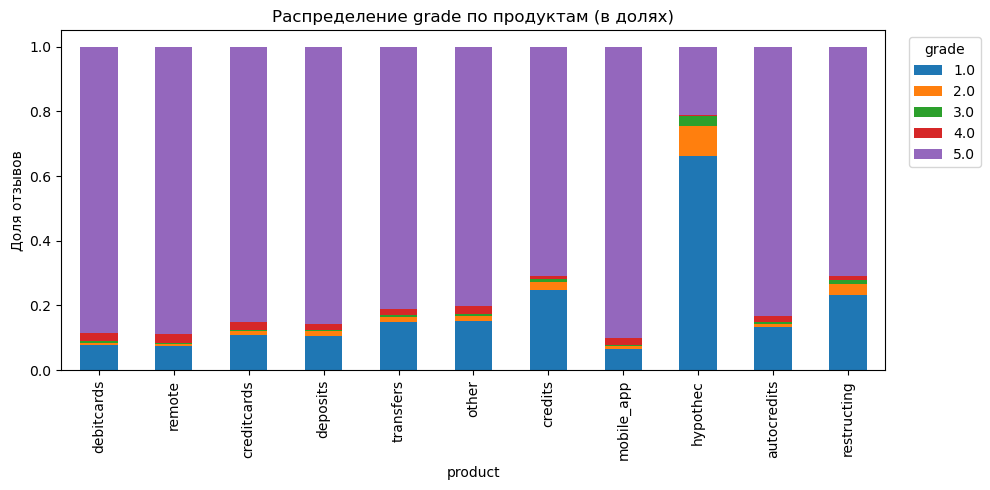

In [13]:
grade_share_product = grade_share_product.loc[g.size().sort_values(ascending=False).index]

grade_share_product.plot(kind='bar', stacked=True, figsize=(10,5), linewidth=0)
plt.ylabel('Доля отзывов')
plt.title('Распределение grade по продуктам (в долях)')
plt.legend(title='grade', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

Продукты у разных банков представлены неравномерно (см. сводную таблицу в ноутбуке **[2.Cleaning&structuring](2.Cleaning&structuring.ipynb)**): например, ~67% отзывов на дебетовые карты принадлежат клиентам Альфа Банка, а ~61% отзывов по ипотеке - клиентам Сбербанка. Поэтому на распределение grade по продукту влияет не только эффект продукта, но и эффект банка.

#### Вывод
Явный отстающий - **ипотека** (hypothec): mean 2, ~70% всех отзывов - grade=1, и лишь ~20% - grade=5. Это резко контрастирует со всеми остальными продуктами. И это вполне логично: ипотека - сложный, долгий, высокорисковый продукт, где недовольство острее и люди пишут отзыв именно когда что-то пошло не так.  

**Кредитные продукты** (credits, restructing, autocredits) - тоже заметно негативнее среднего (20-25% grade=1), что тоже ожидаемо: это тоже "проблемные" по своей природе продукты (просрочки, отказы, реструктуризация).  

**Транзакционные/простые продукты** (debitcards, remote, creditcards, deposits, mobile_app, transfers, other) - почти сплошь позитив (>80% grade=5).  

Важная оговорка, прежде чем делать вывод "транзакционные/простые продукты нравятся клиентам больше": именно debitcards - самая объёмная категория у Альфа-Банка (51 377 из 77 249 по всему датасету) и Совкомбанка, у которых действуют акции за позитивные отзывы. Так что позитивный перекос по дебетовым картам может быть в основном эффектом банков с акциями, а не тем, что дебетовые карты сами по себе вызывают меньше нареканий. Это ровно то, ради чего запланирован анализ среза банк × продукт, чтобы разделить эффект продукта и эффект банка.

## 3. resolutionIsApproved

В ноутбуке **[2.Cleaning&structuring](2.Cleaning&structuring.ipynb)** было обнаружено, что поле resolutionIsApproved заполняется почти исключительно у негативных отзывов; ячейки в колонке заполняются только для отзывов, поданных как жалобы на проблему. Поэтому большинство пропусков (NA) = "отзыв не является жалобой".

Процент заполненности resolutionIsApproved по продуктам:

In [14]:
reviews.groupby('product', observed=False)['resolutionIsApproved'].apply(lambda x: x.notna().mean()*100)

product
autocredits           5.807478
creditcards           5.297718
credits              10.758593
currency_exchange     3.370787
debitcards            3.783721
deposits              5.232782
hypothec             22.828508
individual            0.000000
mobile_app            3.048037
other                 7.141779
remote                3.610849
restructing           9.696570
transfers             6.340221
Name: resolutionIsApproved, dtype: float64

Процент заполненнности resolutionIsApproved по банкам (`fill_rate`) и процент True среди заполненных (`resolved_share`, то есть насколько эффективно банк решает уже поданные жалобы)

In [6]:
resolution_stats = reviews.groupby('bank', observed=False)['resolutionIsApproved'].agg(
    fill_rate=lambda x: x.notna().mean()*100,
    resolved_share=lambda x: x[x.notna()].mean()*100 
)
resolution_stats

,fill_rate,resolved_share
bank,,
alfabank,3.047345,99.673677
sberbank,26.499274,98.981989
sovcombank,3.528416,96.906667
tcs,4.821651,97.526882
vtb,20.970514,96.153846


**По продуктам** всё логично и согласуется с тем, что было видно ранее: больший процент заполенности поля resolutionIsApproved у ипотеки (22.8%), это прямое следствие того, что у этого продукта больше негативных отзывов, жалоб. Далее идут credits (10.8%) и реструктуризация (9.7%) выше остальных. У individual аномальные 0%, но это объясняется очень малым размером выборки.  

**По банкам** обнаружилась аномалия, которая настораживает: `resolved_share` (доля True среди заполненных) у всех пяти банков находится в узком диапазоне 96.1-99.7%, то есть почти все заполненные значения - True. Это подозрительно для метрики, которая должна отражать качество работы банков с жалобами. Возможны два объяснения, и их стоит различить:  
* Банки правда почти всегда решают заявленные проблемы - это тоже валидный вывод, просто тогда сама метрика малоинформативна для сравнения банков (все около 100%, различать особо нечего)
* Более вероятная альтернатива - проблема с интерпретацией поля. Если resolutionIsApproved заполняется только тогда, когда проблема действительно решена (а не в момент подачи жалобы), то NA может означать не только "это не жалоба", но и "жалоба ещё не решена/решение не подтверждено". В таком случае смешиваются две разные группы внутри NA, и resolved_share окажется искусственно близким к 100% почти всегда, вне зависимости от банка - просто по конструкции поля, а не потому что банки одинаково хороши

Посмотрим реальное количество True и False (не только процент) - если False почти нет, это подтвердит вторую версию: поле, скорее всего, устроено как "отметка о факте решения", а не как честный индикатор "решено/не решено" на каждую жалобу.  

In [16]:
reviews['resolutionIsApproved'].value_counts(dropna=False)

resolutionIsApproved
<NA>     166889
True       8262
False       164
Name: count, dtype: Int64

#### Вывод
164 False на весь датасет (175К строк) подтверждает вторую версию, а не первую. Куда вероятнее, что `resolutionIsApproved` устроено как "отметка о факте решения", а не как честный индикатор на каждую жалобу: клиенты просто не всегда доходят до финального шага подтверждения (банк ответил → клиент подтвердил решение).  

Из этого следуют два практических решения:
- **`resolved_share` не используется** как метрика качества банка - она не отражает, насколько хорошо банк решает проблемы
- **`fill_rate` остаётся полезной метрикой**, но переосмыслена: это не просто доля жалоб, а доля отзывов, дошедших до полного цикла жалоба → ответ → подтверждение

## 4. Разница между банками при одинаковом продукте

До настоящего момента данные рассматривались в разрезе по банкам и в разрезе по продуктам. Но продукты в каждом банке представлены в разных объемах (например, у Сбербанка непропорционально много ипотеки, у Альфы - мало ипотеки и много дебетовых карт). Поэтому сравнение "в среднем" может частично отражать не качество банка, а то, какие продукты у него больше представлены в датасете. И наоборот: продукт, большинство отзывов по которому принадлежат банку с более высоким базовым grade, может иметь более высокие оценки именно благодаря эффекту банка.  
Чтобы отделить эффект банка от эффекта продукта, посмотрим на данные в разрезе банк x продукт - то есть сравним банки в рамках одного и того же продукта.

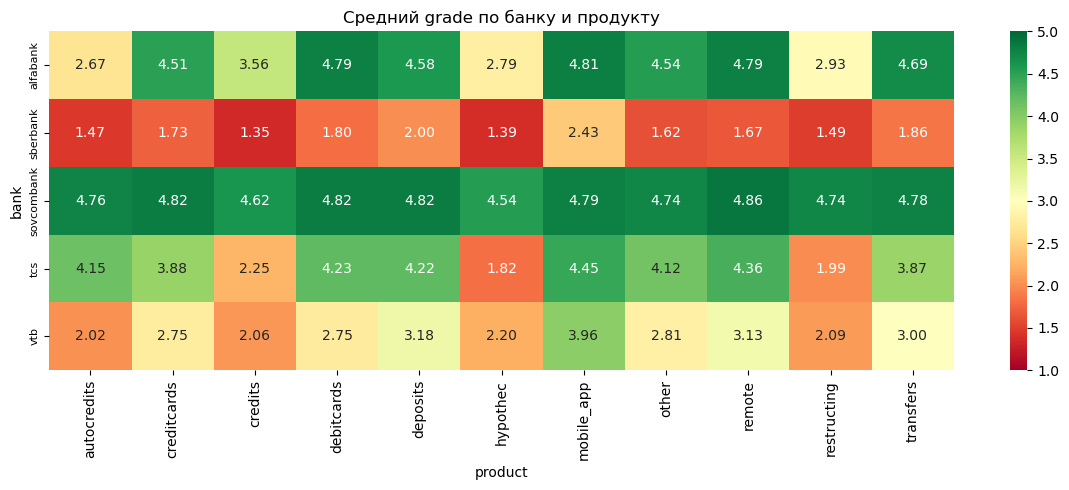

In [17]:
reviews_filtered = reviews[~reviews['product'].isin(['individual', 'currency_exchange'])]

pivot_grade = reviews_filtered.pivot_table(
    index='bank',
    columns='product',
    values='grade',
    aggfunc='mean',
    observed=True
)

plt.figure(figsize=(12, 5))
sns.heatmap(pivot_grade, annot=True, fmt='.2f', cmap='RdYlGn', vmin=1, vmax=5)
plt.title('Средний grade по банку и продукту')
plt.yticks(fontsize=8, ha='right')
plt.tight_layout()
plt.show()

Выше - средний grade по каждой паре банк-продукт. Чем зеленее ячейка, тем выше средняя оценка.

In [18]:
pivot_count = reviews_filtered.pivot_table(
    index='bank',
    columns='product',
    values='grade',
    aggfunc='count',
    observed=True
)
pivot_count.style.background_gradient(cmap='Reds_r', vmin=0, vmax=200)

product,autocredits,creditcards,credits,debitcards,deposits,hypothec,mobile_app,other,remote,restructing,transfers
bank,,,,,,,,,,,
alfabank,45,8899,777,51375,2438,200,2402,2797,17849,129,3541
sberbank,75,407,227,925,177,1656,42,280,577,87,359
sovcombank,1872,11909,3131,14560,3949,335,876,2130,11629,1039,1694
tcs,418,2793,364,7487,639,185,524,1000,4797,168,887
vtb,104,661,418,2902,593,318,257,416,1205,93,584


В таблице выше в каждой ячейке количество отзывов по паре банк-продукт. Это нужно, чтобы понимать, на каком объёме данных посчитано среднее из графика выше: там, где отзывов мало, среднее может быть неустойчивым и не заслуживает содержательной интерпретации.

#### Вывод

**Эффект банка доминирует над эффектом продукта.** У Совкомбанка даже ипотека (`hypothec` = 4.54) - обычно самый "проблемный" продукт во всём датасете (общее среднее 2) - оказывается почти такой же позитивной, как остальные продукты банка. То же у Альфы: её ипотека (2.79) заметно ниже остальных продуктов банка, но всё равно почти вдвое выше, чем ипотека у Сбера (1.39). То есть денежный стимул не просто добавляет позитива в среднем - он перекрывает даже проблемные продукты.  

**Но не полностью.** Внутри Альфы, Совкомбанка и Т-Банка ипотека, реструктуризация и автокредиты всё равно ниже остальных продуктов. Акция сглаживает, но не устраняет продуктовый эффект полностью - негатив связанный с проблемными продуктами всё равно просачивается.  

**У Т-Банка отдельно выделяются `hypothec` (1.82) и `restructing` (1.99)** - резко ниже остальных продуктов банка, почти на уровне Сбербанка/ВТБ. Это может быть следствием того, что акция у Т-Банка либо слабее, либо не покрывает эти конкретные продукты - негатив по проблемным продуктам здесь проявляется сильнее, чем у Альфы/Совкомбанка.

**Осторожно с интерпретацией отдельных ячеек с малым n**: `alfabank`/`autocredits` (45) и `sberbank`/`mobile_app` (42) - по ним не стоит делать содержательных выводов в силу недостаточности данных. `sberbank`/`autocredits` (75) и реструктуризация у нескольких банков (87-93, 129, 168) - на грани, интерпретировать можно, но с оговоркой на небольшой объём.

## 5. Динамика по месяцам (grade и количество отзывов)
Датасет охватывает период длинною в год, поэтому хочется посмотреть на данные не только как на что-то статичное, но и в динамике. Год - это достаточно длинный период, чтобы в нём могли происходить изменения: сезонные колебания, разовые события, сдвиги в поведении банков или клиентов. Посмотрим на динамику по месяцам, чтобы увидеть, стабильна ли картина во времени или в ней есть периоды, которые выделяются на общем фоне.

**Важное замечание по методологии:** последний месяц периода (август 2026) исключён из графиков - данные собраны только до 28.08.2026, то есть месяц неполный, и его включение исказило бы динамику (создало бы ложное впечатление резкого спада в конце).

### 5.a По банкам
Сначала построим общий график динамики по всем пяти банкам сразу, чтобы увидеть картину целиком.

In [19]:
reviews_full_months_by_bank = reviews_by_bank[reviews_by_bank['dateCreate'] < '2026-08-01']

monthly_bank = (
    reviews_full_months_by_bank
    .groupby([pd.Grouper(key='dateCreate', freq='ME'), 'bank'], observed=True)
    .agg(avg_grade=('grade', 'mean'), n_reviews=('grade', 'count'))
    .reset_index()
)

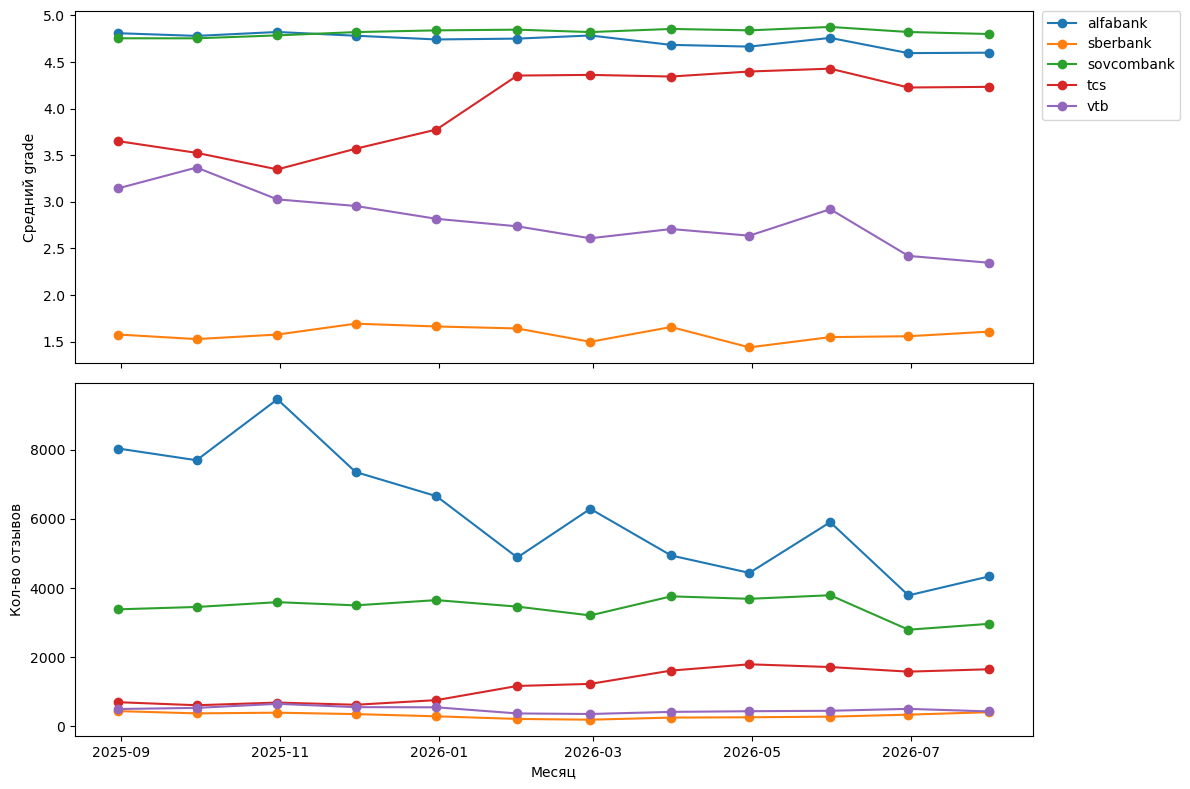

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for bank in monthly_bank['bank'].unique():
    sub = monthly_bank[monthly_bank['bank'] == bank]
    axes[0].plot(sub['dateCreate'], sub['avg_grade'], marker='o', label=bank)
    axes[1].plot(sub['dateCreate'], sub['n_reviews'], marker='o', label=bank)

axes[0].set_ylabel('Средний grade')
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0) 
axes[1].set_ylabel('Кол-во отзывов')
axes[1].set_xlabel('Месяц')
plt.tight_layout()
plt.show()

**По grade:**
* Банки чётко делятся на три уровня: Альфа и Совкомбанк держатся вверху весь период (4.5-5.0), Т-Банк - в середине, ВТБ и Сбербанк - внизу  
* Сбербанк держится на одном уровне (1.5-1.7) практически без изменений весь год  
* Т-Банк - единственный, кто показывает явный восходящий тренд: рост с ~3.5 в начале до ~4.5 к середине периода, дальше выходит на плато  
* Альфа и Совкомбанк почти весь период идут вместе и близко друг к другу, но ближе к концу расходятся - Альфа немного снижается, Совкомбанк держится стабильно  
* ВТБ колеблется, но в целом слегка снижается к концу периода, с заметным провалом в мае-июне и частичным восстановлением перед новым падением  

**По объёму отзывов:**
* Альфа-Банк резко выделяется объёмом на фоне остальных (в разы больше) и при этом самый нестабильный - от ~4000 до ~9000, с пиком в ноябре 2025 и общим нисходящим трендом  
* Совкомбанк держит стабильный объём почти весь период
* Т-Банк показывает явный рост объёма начиная примерно с января-февраля 2026 - почти удваивает объем к середине года
* Сбербанк и ВТБ - стабильно небольшой объём на протяжении почти всего периода, у ВТБ заметен небольшой всплеск в октябре-ноябре 2025

**Проблема этого графика:** разница в масштабе между банками (grade у Сбера в районе 1.5, у Альфы под 5.0; объём у Альфы в 10+ раз больше, чем у Сбера/ВТБ) не даёт разглядеть детали внутри каждого банка - например, тонкие колебания grade у Сбербанка теряются на фоне общего диапазона графика. Поэтому следующий шаг - отдельные графики с независимым масштабом для каждого банка.

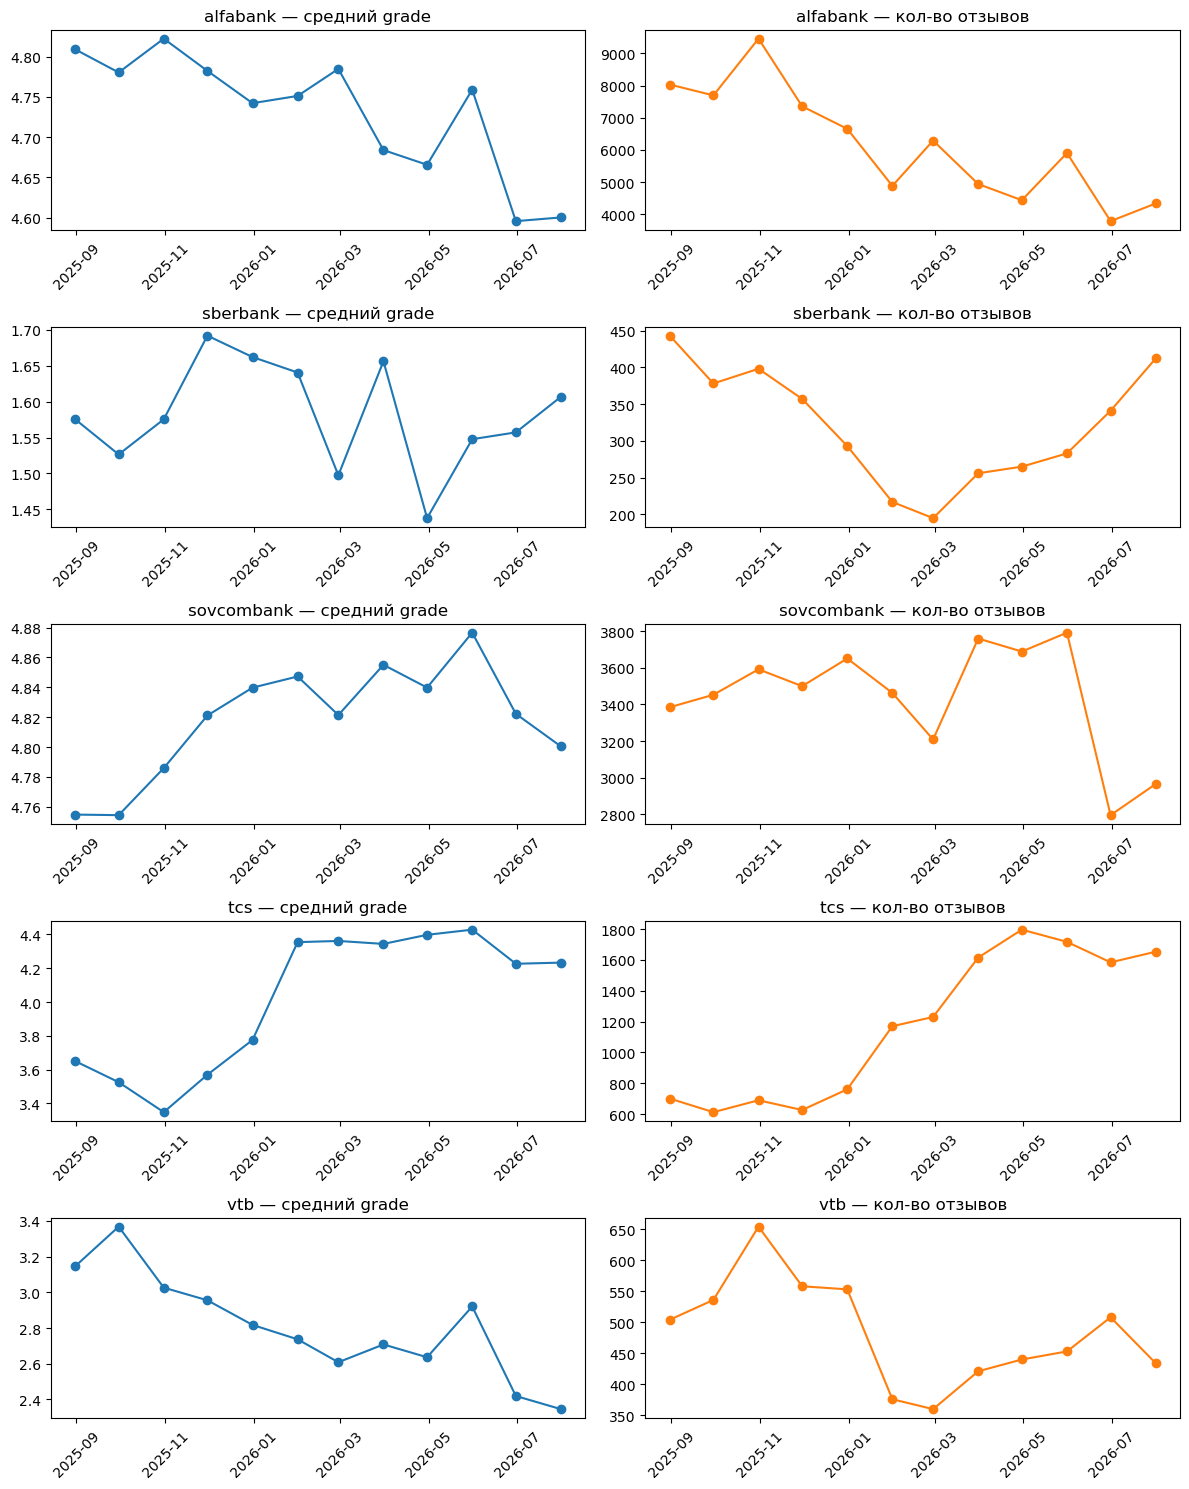

In [21]:
banks = monthly_bank['bank'].unique()
fig, axes = plt.subplots(len(banks), 2, figsize=(12, 3*len(banks)))

for i, bank in enumerate(banks):
    sub = monthly_bank[monthly_bank['bank'] == bank]
    
    axes[i, 0].plot(sub['dateCreate'], sub['avg_grade'], marker='o', color='tab:blue')
    axes[i, 0].set_title(f'{bank} — средний grade')
    axes[i, 0].tick_params(axis='x', rotation=45)
    
    axes[i, 1].plot(sub['dateCreate'], sub['n_reviews'], marker='o', color='tab:orange')
    axes[i, 1].set_title(f'{bank} — кол-во отзывов')
    axes[i, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Т-Банк - самая явная синхронность.** Оценка и объём движутся практически вместе на всём протяжении графика: обе линии растут одновременно с ноября-декабря 2025 по февраль-март 2026, выходят на плато примерно в одной точке (апрель-май), и обе синхронно немного просаживаются к июлю.  

**Совкомбанк - синхронность проявляется только в конце.** Большую часть года линии ведут себя независимо: grade стабильно растёт, а объём колеблется вокруг одного уровня без явного тренда. Но в предпоследней точке обе линии резко падают одновременно — это единственный момент совместного движения за весь период, и именно поэтому он выделяется как аномалия, заслуживающая отдельной проверки.

**Альфа-Банк - умеренная синхронность на общем фоне снижения.** Обе линии в целом снижаются к концу периода и дают общий пик примерно в одной точке (ноябрь 2025), но между пиком и концом периода движутся не строго вместе - объём колеблется заметно сильнее, чем оценка, которая почти весь год держится в узком диапазоне.

**Сбербанк - линии двигаются независимо друг от друга.** Ни рост, ни падение объёма не сопровождаются соответствующим движением оценки - колебания grade выглядят как отдельный, не связанный с объёмом процесс.

**ВТБ - слабая, шумная синхронность.** Есть отдельные точки, где линии движутся в одном направлении (например, общий спад к февралю-марту 2026), но в целом совпадение частичное и менее выраженное, чем у Т-Банка или Совкомбанка.  

#### Вывод

Синхронное движение grade и объёма отзывов само по себе не доказывает причинно-следственную связь, но именно там, где такая синхронность видна, есть наиболее убедительные кандидаты на содержательное объяснение.  
Наиболее правдоподобное объяснение для Т-Банка и Совкомбанка - изменение условий акций за отзывы в эти периоды, но в рамках этого проекта эта связь не проверялась напрямую (например, сверкой с официальными датами изменения условий акций) и остаётся гипотезой, а не подтверждённым фактом.

### 5.b По продуктам

Аналогично посмотрим на динамику по месяцам, но в разрезе продуктов вместо банков. Здесь стоит держать в уме важную оговорку: продукты у разных банков представлены неравномерно (это мы уже видели в разделе 4), поэтому динамика по продукту может отражать не только особенности самого продукта, но и то, что происходит у конкретного банка, который в нём доминирует по объёму.

In [22]:
reviews_filtered = reviews[~reviews['product'].isin(['individual', 'currency_exchange'])]
reviews_full_months = reviews_filtered[reviews_filtered['dateCreate'] < '2026-08-01']

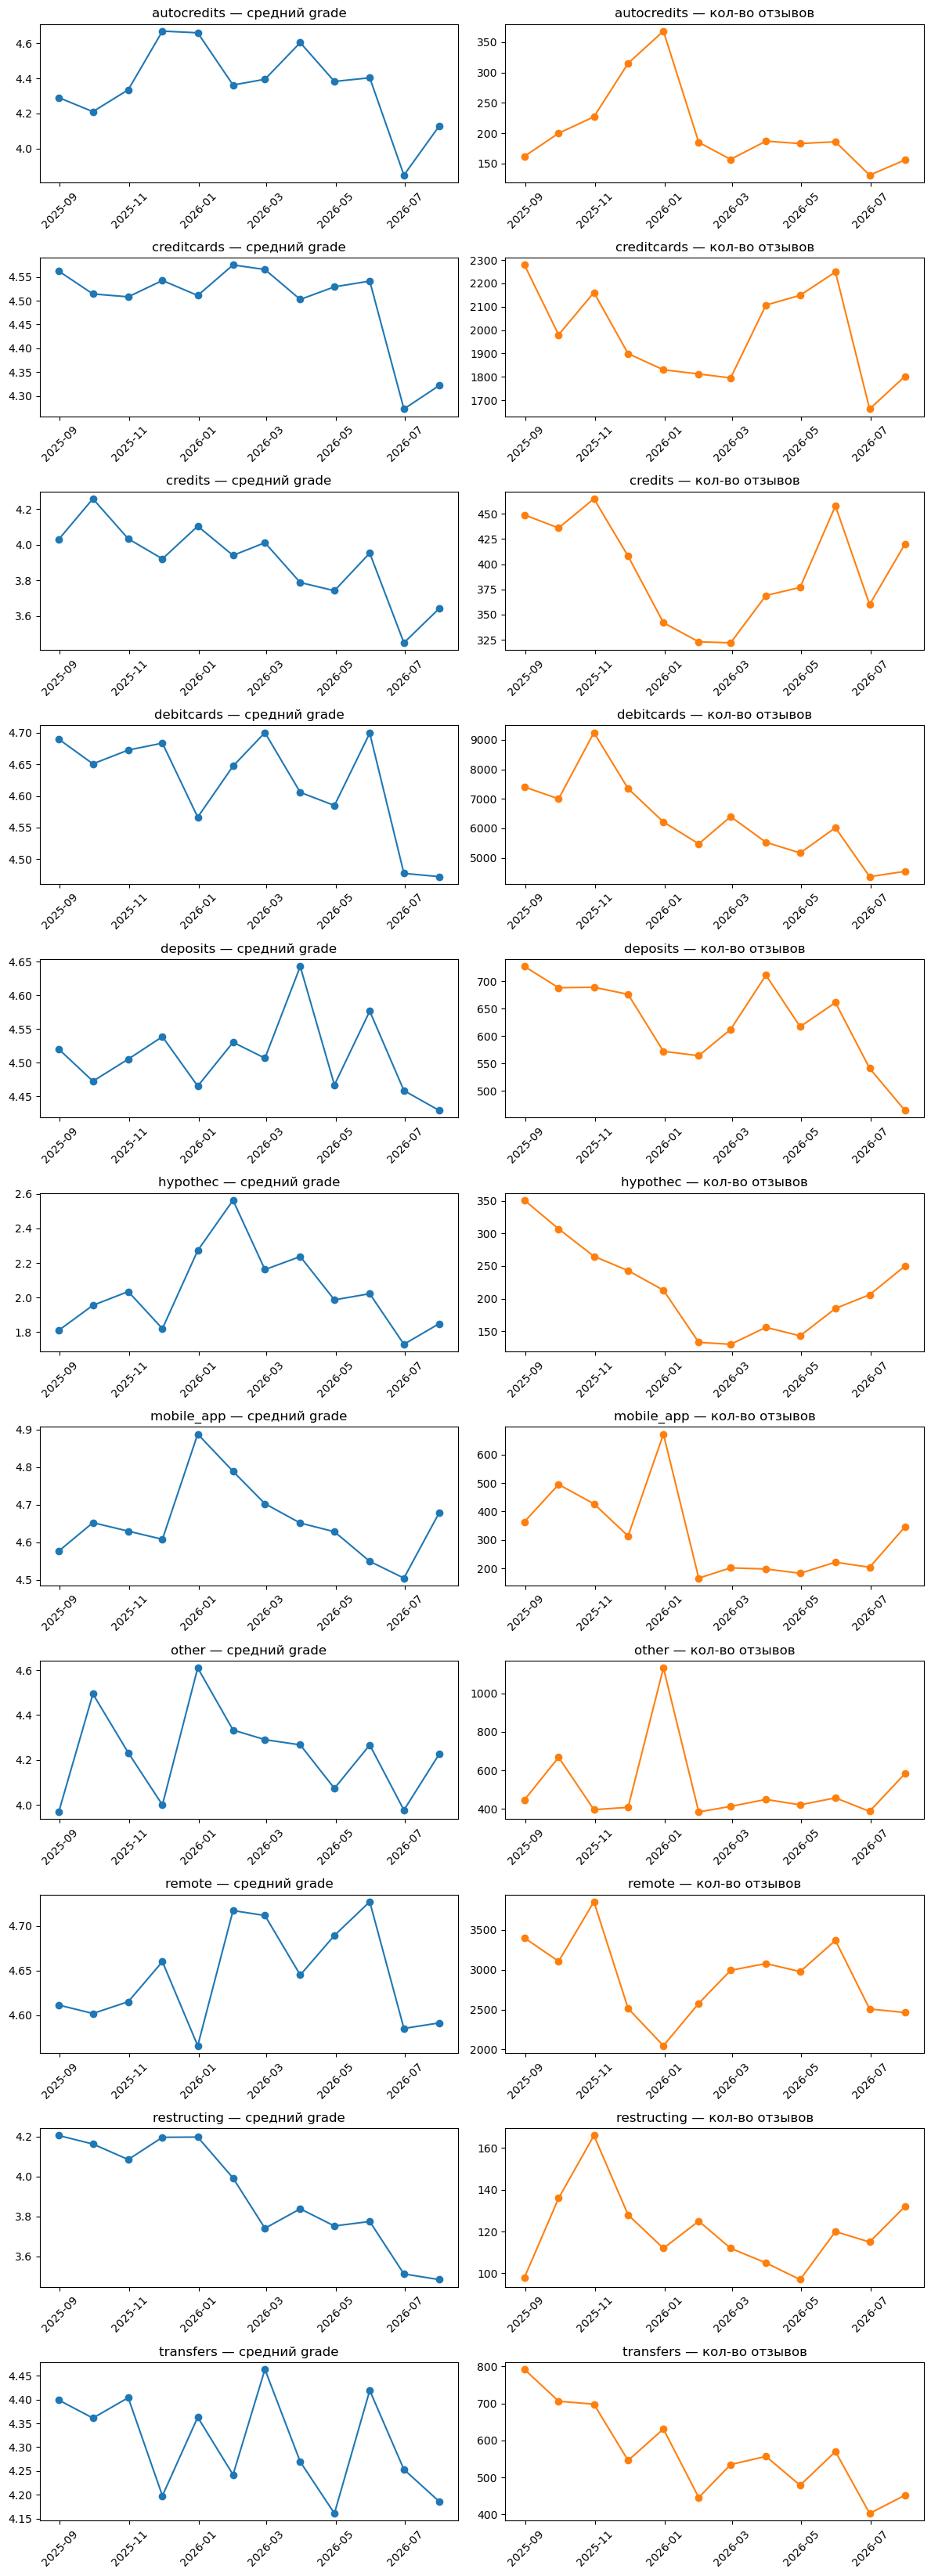

In [23]:
monthly_product = (
    reviews_full_months
    .groupby([pd.Grouper(key='dateCreate', freq='ME'), 'product'], observed=True)
    .agg(avg_grade=('grade', 'mean'), n_reviews=('grade', 'count'))
    .reset_index()
)

products = sorted(monthly_product['product'].unique())
fig, axes = plt.subplots(len(products), 2, figsize=(12, 3*len(products)))

for i, product in enumerate(products):
    sub = monthly_product[monthly_product['product'] == product]
    
    axes[i, 0].plot(sub['dateCreate'], sub['avg_grade'], marker='o', color='tab:blue')
    axes[i, 0].set_title(f'{product} — средний grade')
    axes[i, 0].tick_params(axis='x', rotation=45)
    
    axes[i, 1].plot(sub['dateCreate'], sub['n_reviews'], marker='o', color='tab:orange')
    axes[i, 1].set_title(f'{product} — кол-во отзывов')
    axes[i, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

У большинства продуктов (`autocredits`, `creditcards`, `credits`, `debitcards`, `hypothec`) к концу периода (июль 2026) заметен спад grade. Вероятное объяснение: этот спад - отражение уже найденного ранее банковского тренда (в разделе 5.a Альфа-Банк, Т-Банк и ВТБ все просели именно в этом месяце), а не независимая продуктовая находка.  

На фоне общего июльского спада отдельно выделяются два продукта с собственным, самостоятельным паттерном:
- **`hypothec`** - заметный скачок grade в январе-феврале 2026 (примерно с 1.9 до 2.3) на фоне провала объёма (падение с ~350 в сентябре до ~140 к февралю-марту, затем постепенное восстановление к июлю). Меньше отзывов, но заметно позитивнее в этот период - что стоит за этим, пока не ясно
- **`mobile_app` и `other`** - резкий синхронный скачок и по grade, и по объёму ровно в январе 2026 (у `mobile_app`: объём 300→650, grade 4.6→4.9; у `other`: объём почти утроился, 400→1200). Одновременный скачок сразу двух метрик у двух разных продуктов в один и тот же месяц - пока неясно, что стоит за этим
- **`restructing`** не показывает похожего паттерна — здесь, наоборот, планомерное снижение grade в течение всего года (без резких скачков), при этом объём остаётся в целом стабильным. То есть в отличие от ипотеки, где менялось и то, и другое, у реструктуризации меняется только оценка, а не сама готовность писать отзывы.

Чтобы сравнить продукты по масштабу изменений (а не только по виду на собственной оси), нормализуем каждый ряд к своему стартовому значению (индекс = 100 в первый месяц).

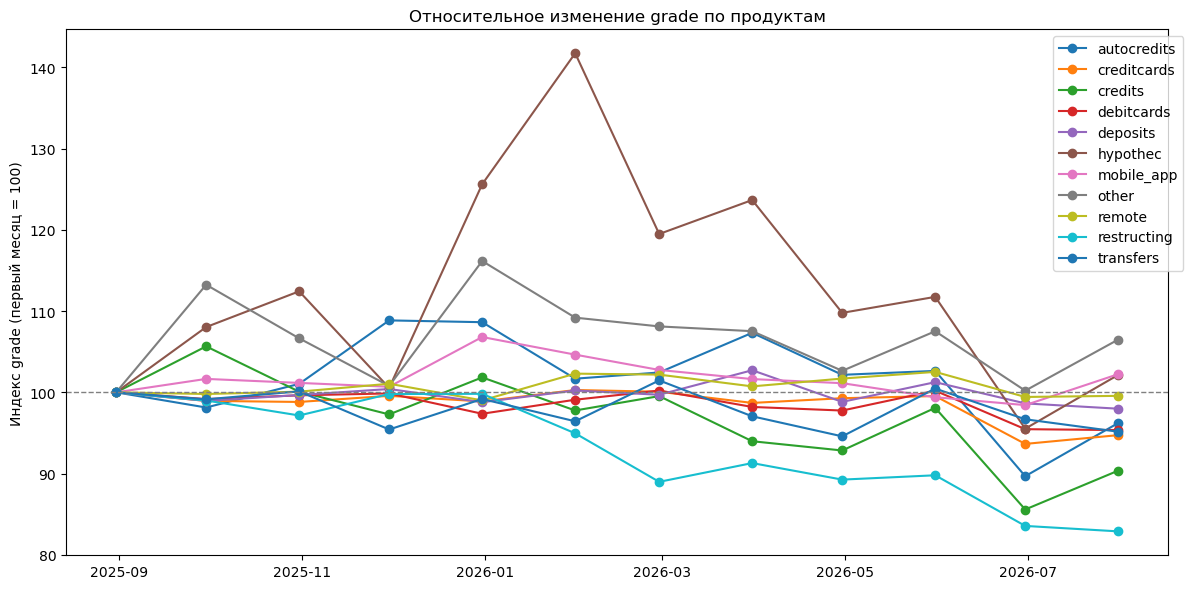

In [24]:
monthly_product_pivot = monthly_product.pivot(index='dateCreate', columns='product', values='avg_grade')
normalized = monthly_product_pivot / monthly_product_pivot.iloc[0] * 100

plt.figure(figsize=(12, 6))
for product in normalized.columns:
    plt.plot(normalized.index, normalized[product], marker='o', label=product)

plt.axhline(100, color='gray', linestyle='--', linewidth=1)
plt.ylabel('Индекс grade (первый месяц = 100)')
plt.title('Относительное изменение grade по продуктам')
plt.legend(bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

`hypothec` - вне конкуренции по амплитуде: индекс доходит до 140 в феврале 2026, то есть grade вырос на 42% относительно старта - кратно больше, чем у любого другого продукта. `other` - второй по масштабу, с похожим, но более сглаженным пиком (~116). `mobile_app` при пересчёте выглядит куда скромнее, чем казалось на собственном графике (пик ~107) - абсолютный скачок был заметен глазу, но относительно это довольно умеренное изменение.  

Отдельно заметен `restructing`: устойчивое снижение до индекса ~83 к концу периода без единого отскока вверх - самое стабильное направленное изменение среди всех продуктов.  

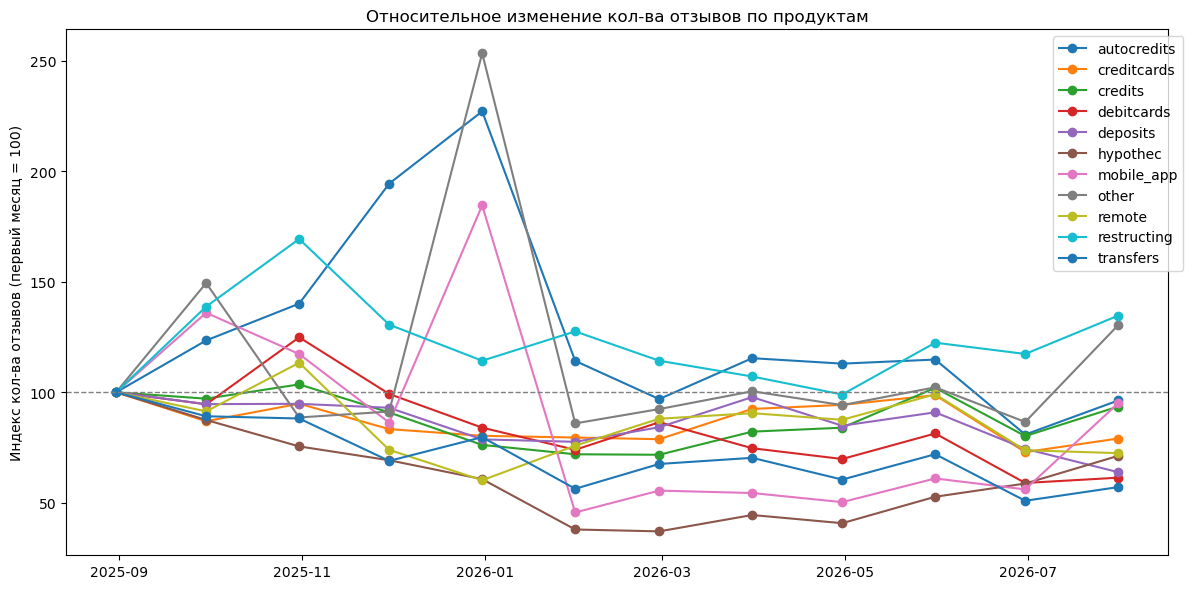

In [25]:
monthly_product_pivot = monthly_product.pivot(index='dateCreate', columns='product', values='n_reviews')
normalized = monthly_product_pivot / monthly_product_pivot.iloc[0] * 100

plt.figure(figsize=(12, 6))
for product in normalized.columns:
    plt.plot(normalized.index, normalized[product], marker='o', label=product)

plt.axhline(100, color='gray', linestyle='--', linewidth=1)
plt.ylabel('Индекс кол-ва отзывов (первый месяц = 100)')
plt.title('Относительное изменение кол-ва отзывов по продуктам')
plt.legend(bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

Ровно в январе 2026 происходит синхронный резкий скачок объёма сразу у трёх продуктов: `other` (индекс ~250, рост в 2.5 раза), `autocredits` (~225, рост более чем вдвое) и `mobile_app` (~180). Три разных продукта одновременно дают экстремальный всплеск в один и тот же месяц - маловероятно, что это случайность или независимые продуктовые тренды по каждому из них.

При этом по объёму `restructing` не показывает того устойчивого снижения, которое видно у него по grade - то есть находка "реструктуризация ухудшается" относится именно к оценкам, а не к объёму: это два разных, не связанных друг с другом сигнала.  

#### Вывод

Динамика по продуктам в основном подтверждает и уточняет то, что уже видно на уровне банков (общий спад в июле - отражение банковского тренда, а не новая находка), но выявляет и два самостоятельных паттерна, не сводящихся напрямую к найденному ранее:

- **`hypothec`** - самая большая относительная амплитуда изменения grade за весь период, с синхронным (хоть и менее выраженным) провалом объёма в тот же момент
- **Тройной синхронный скачок объёма** (`other`, `autocredits`, `mobile_app`) ровно в январе 2026 - на трёх независимых продуктах одновременно, что делает случайное совпадение маловероятным
- **`restructing`** - единственный продукт, где направленное изменение видно только в оценках, но не в объёме, что отличает его от остальных найденных паттернов

Оба явления интересны сами по себе, но требуют более глубокого разбора, чтобы понять, чем именно они объясняются.

## 6. Длина текста vs grade

Прежде чем переходить к анализу самого текста отзывов, проверим одну базовую характеристику - как длина отзыва связана с оценкой. Это пригодится и как самостоятельное наблюдение, и как контекст для дальнейшего анализа: если тексты разной длины систематически отличаются по оценке, это стоит учитывать при работе с текстом дальше.

In [26]:
reviews_by_bank.groupby('grade')['text_len'].describe()

,count,mean,std,min,25%,50%,75%,max
grade,,,,,,,,
1.0,14129.0,1363.534504,869.481010,77.0,681.00,1131.0,1829.00,3827.0
2.0,1592.0,1297.527010,818.744186,113.0,669.75,1071.0,1734.00,3619.0
3.0,674.0,1156.132047,778.509533,57.0,565.50,935.0,1509.25,3603.0
4.0,3502.0,699.269846,524.076274,106.0,358.00,510.0,832.75,3604.0
5.0,124196.0,575.894554,364.201606,62.0,341.00,444.0,669.00,3608.0


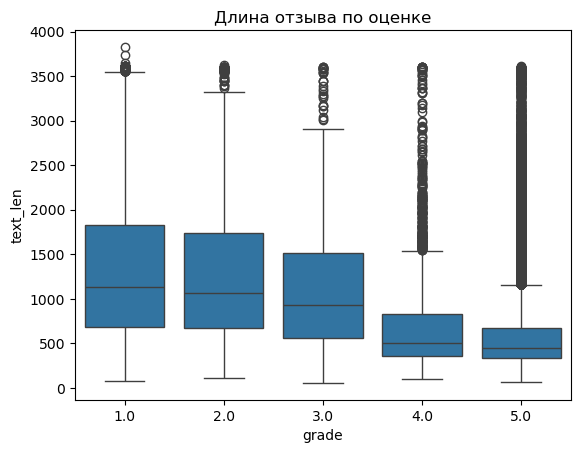

In [27]:
sns.boxplot(data=reviews_by_bank, x='grade', y='text_len')
plt.title('Длина отзыва по оценке')
plt.show()

#### Вывод
Чёткий и ожидаемый паттерн: чем ниже оценка, тем длиннее текст. Медиана падает почти монотонно от 1131 символов (grade=1) до 444 (grade=5) - почти в 2.5 раза. Это логично: жалоба требует описать проблему и контекст, что банк сделал не так, тогда как позитивный отзыв часто ограничивается парой предложений благодарности.

Стоит держать в уме и объём выборки по средним категориям: 3.0 и 4.0 - не очень большие группы (674 и 3502) относительно 1.0 и 5.0 (14129 и 124196) — асимметрия ожидаема (5.0 доминирует за счёт Альфы/Совкомбанка), но не стоит забывать об этом при визуальном сравнении графика.

## 7. Общий частотный анализ по продуктам

Прежде чем переходить к более точечным разборам, посмотрим на частотный анализ слов в жалобах (grade=1) по каждому продукту отдельно - это даст общее представление о том, какие темы чаще всего поднимаются в негативных отзывах, и послужит основой для более предметного анализа дальше.

In [38]:
from sklearn.feature_extraction.text import CountVectorizer

russian_stopwords = ['и', 'в', 'не', 'на', 'что', 'с', 'по', 'это', 'как', 'из',
                      'за', 'то', 'все', 'его', 'но', 'от', 'мне', 'к', 'у', 'я',
                      'бы', 'для', 'мой', 'банк', 'банка', 'банке', 'так', 'при', 
                      'меня', 'было', 'уже', 'после', 'нет', 'через', 'только',
                      'был', 'они', 'чтобы', 'без', 'раз']  # можно дополнить

complaints = reviews_full_months[reviews_full_months['grade'] == 1]

for product in complaints['product'].unique():
    texts = complaints[complaints['product'] == product]['text']
    
    vectorizer = CountVectorizer(stop_words=russian_stopwords, max_features=15, token_pattern=r'[а-яё]{3,}')
    word_counts = vectorizer.fit_transform(texts)
    
    words = vectorizer.get_feature_names_out()
    counts = word_counts.sum(axis=0).A1.tolist()
    top = sorted(zip(words, counts), key=lambda x: -x[1])
    
    print(f"\n=== {product} ===")
    print(top)


=== hypothec ===
[('домклик', 2454), ('сбербанк', 1754), ('плюс', 1572), ('договора', 1184), ('жизни', 1132), ('ставки', 1002), ('документы', 944), ('года', 926), ('ипотеку', 917), ('договор', 907), ('страхование', 870), ('услуг', 856), ('ипотеки', 852), ('ставка', 850), ('ипотеке', 848)]

=== autocredits ===
[('кредит', 225), ('авто', 204), ('автокредит', 178), ('условия', 174), ('деньги', 173), ('день', 163), ('кредита', 159), ('года', 153), ('залог', 150), ('документы', 142), ('рублей', 135), ('нужно', 129), ('дней', 126), ('обращение', 124), ('втб', 123)]

=== credits ===
[('кредит', 1597), ('кредита', 883), ('деньги', 722), ('втб', 562), ('день', 562), ('сумму', 505), ('года', 502), ('если', 484), ('платеж', 470), ('обращение', 468), ('сотрудник', 467), ('кредиту', 458), ('вопрос', 455), ('платежа', 454), ('была', 447)]

=== restructing ===
[('документы', 188), ('сотрудник', 181), ('кредит', 177), ('чате', 174), ('условия', 173), ('кредита', 170), ('дней', 168), ('была', 164), ('

#### Вывод

**`hypothec` - сильная находка.** Топ включает `договора`, `жизни`, `ставки`, `страхование`, `ипотеки`/`ипотеке` - судя по сочетанию "жизни" + "страхование" + "договора", это, скорее всего, классическая для российского рынка жалоба на навязанное страхование жизни при оформлении ипотеки. Это самостоятельная находк - стоит выборочно прочитать несколько отзывов с этими словами, чтобы подтвердить формулировку.

**Сквозная тема - `сотрудник` встречается в топе почти у всех продуктов** (`credits`, `restructing`, `deposits`, `creditcards`, `debitcards`) - похоже, качество работы персонала/поддержки - это общая болевая точка, независимо от продукта.

## Гипотезы для проверки в следующем ноутбуке

По итогам EDA сформировался список направлений, которые требуют более точечной проверки:

1. **Влияние платных акций за отзывы на рейтинг банка** - центральная гипотеза исследования. У Альфа-Банка, Совкомбанка и Т-Банка есть денежные вознаграждения за отзыв с оценкой 4-5; у Сбербанка и ВТБ таких акций нет. Наблюдаемое распределение оценок согласуется с этой гипотезой, но требует формального статистического подтверждения (chi-square, Cramer's V).

2. **Скачок `hypothec` в январе-феврале 2026** - рост среднего grade на фоне провала объёма отзывов. Требуется проверить, связан ли этот период с содержательным сдвигом в текстах отзывов (например, снижением доли жалоб на навязанное страхование).

3. **Устойчивое снижение `restructing` за год** - планомерное падение среднего grade без соответствующего снижения объёма. Требуется проверить, объясняется ли это долей конкретных банков в выборке или это независимый от банков тренд.